# Reto 4 — Deep Q-Learning aplicado a **Asignación de Portafolio**

**Maestría en Ciencia de Datos y Analítica — Universidad EIA**
**Curso:** Aprendizaje por Refuerzo
**Tema:** *Deep Q-Learning Applied to Algorithmic Trading*

---

### Qué cambia respecto a la versión de un solo activo

La primera versión de este reto entrenaba al agente sobre **una sola serie de precios sintética**
(movimiento browniano geométrico), con acciones `hold / buy / sell`. Esta versión lo extiende en dos
direcciones:

1. **Datos reales** descargados de Yahoo Finance (`yfinance`) en lugar de datos sintéticos.
2. **Portafolio multi-activo**: el agente decide **en cuál de varios activos estar posicionado**
   (o quedarse en efectivo), en vez de operar un único instrumento.

### Por qué *esta* formulación de portafolio y no otra

Un portafolio "clásico" asigna **pesos continuos** (30% AAPL, 20% MSFT, …). Esa formulación
**no es compatible con DQN**: DQN elige acciones mediante $\arg\max_a Q(s,a)$, lo que exige un
espacio de acciones **discreto y finito**. Pesos continuos requerirían algoritmos de política
(DDPG, PPO, SAC), que quedan fuera del alcance de este reto.

Tampoco sirve mantener `hold/buy/sell` **por activo**: con $N$ activos el espacio de acciones
crece como $3^N$ (con 10 activos serían 59.049 acciones — inviable).

La formulación que adoptamos mantiene DQN intacto:

$$\mathcal{A} = \{\,\text{efectivo},\ \text{activo}_1,\ \dots,\ \text{activo}_N\,\}
\quad\Rightarrow\quad |\mathcal{A}| = N + 1$$

En cada paso el agente mantiene **el 100% del capital en exactamente una posición**. Esto es
*asignación de portafolio* legítima (rotación entre activos según el régimen de mercado), sigue
siendo Q-learning puro, y el $\arg\max$ funciona sobre apenas $N+1$ acciones.

### Resumen del resultado (adelanto honesto)

El agente **no supera de forma fiable** al baseline de portafolio equiponderado (1/N). Al repetir
el entrenamiento con varias semillas, los resultados de test se dispersan enormemente —de un
extremo positivo a fuertemente negativo— y la mayoría queda por debajo del baseline. Sí supera
con claridad a un agente aleatorio, y aprende a reducir sus rotaciones para no quemar capital
en comisiones.

> Los valores numéricos concretos varían en cada ejecución (los datos se descargan en vivo y el
> entrenamiento es estocástico). Lo estable es el **patrón**: dispersión alta y ausencia de ventaja
> consistente sobre el 1/N.

Este notebook trata ese resultado negativo como el hallazgo central y dedica dos secciones
(9.1 y 9.2) a demostrar *por qué* es el número creíble, frente a una curva de entrenamiento que
—por sobreajuste— sugeriría rendimientos de +7.000%.

### Fuentes y adaptación (declaración de honestidad académica)

- **Ejemplo base de inspiración:** dima806, *"Deep Q-Learning Algorithmic Trading Example"*, Kaggle.
  `https://www.kaggle.com/code/dima806/deep-q-learning-algorithmic-trading-example`
- **Guía teórica principal:** material de clase *"Aprendizaje reforzado — Deep Q-Learning"*
  (J. C. Tejada, U. EIA), Lapan (*Deep RL Hands-On*, Cap. 8 y 10) y Sanghi
  (*Deep RL with Python*, Cap. 13).
- **Adaptación propia:** el ambiente multi-activo, la formulación del espacio de acciones como
  rotación entre activos, el manejo de costos de transacción al rotar y los *baselines* de
  comparación son desarrollo propio para este reto.

## 1. Instalar / importar librerías

Usamos PyTorch para la red neuronal, NumPy/Pandas para datos, Matplotlib para gráficas y
`yfinance` para descargar precios reales.

Igual que en la versión anterior, **no usamos Gymnasium directamente** porque construimos nuestro
propio ambiente, pero seguimos **la misma interfaz** (`reset()` / `step()`) que define su API.

> **Nota de entorno (Anaconda + PyTorch en Windows).** La primera celda fija dos variables de
> entorno antes de importar nada. Sin ellas, el kernel muere con `OMP: Error #15` porque Anaconda
> (vía MKL) y PyTorch cargan cada uno su propia copia del runtime de OpenMP. Es un problema de
> instalación, no del algoritmo, pero conviene dejarlo resuelto para que el notebook corra en
> cualquier máquina.

In [1]:
# Si falta alguna dependencia, descomentar:
# !pip install torch yfinance

# --- Conflicto de OpenMP (Anaconda + PyTorch en Windows) ---
# Anaconda trae numpy enlazado con MKL, que carga libiomp5md.dll; PyTorch carga su propia
# copia del mismo runtime. Al coexistir, Windows aborta el proceso con "OMP: Error #15" y
# el kernel de Jupyter MUERE sin traza util.
# Estas dos lineas deben ejecutarse ANTES de importar numpy o torch.
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"   # permite la doble carga
os.environ["OMP_NUM_THREADS"] = "1"           # 1 hilo: evita la contencion entre ambos runtimes

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import random
import copy
import collections
from collections import deque

# Semillas para reproducibilidad del AGENTE
# (Nota: los datos se descargan en vivo, ver seccion 2.)
SEED = 42
np.random.seed(SEED)
random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Dispositivo:", DEVICE)
print("PyTorch:", torch.__version__)

Dispositivo: cpu
PyTorch: 2.8.0+cpu


## 2. Datos reales: descarga desde Yahoo Finance

Descargamos precios de cierre **ajustados** (`auto_adjust=True`, que corrige *splits* y dividendos —
sin este ajuste un *split* aparecería como una caída del 50% y envenenaría los retornos).

### Selección de activos

Elegimos 4 activos de **sectores distintos** a propósito: si todos fueran tecnológicas, sus precios
estarían tan correlacionados que la decisión de "en cuál estar" sería casi irrelevante y el agente
no tendría nada que aprender.

| Ticker | Empresa | Sector |
|---|---|---|
| `AAPL` | Apple | Tecnología / hardware |
| `MSFT` | Microsoft | Tecnología / software |
| `GOOGL` | Alphabet | Comunicaciones / publicidad |
| `JNJ` | Johnson & Johnson | Salud (defensivo) |

`JNJ` cumple un papel especial: es un activo **defensivo**, que suele caer menos en mercados
bajistas. Da al agente algo útil que hacer cuando la tecnología cae.

> ### ⚠️ Limitación declarada: dependencia de internet
>
> Este notebook descarga los datos **en vivo en cada ejecución**. Esto implica dos limitaciones
> que declaramos explícitamente por honestidad metodológica:
>
> 1. **Requiere conexión a internet** al momento de ejecutar.
> 2. **La reproducibilidad exacta no está garantizada**: `yfinance` es un cliente no oficial y
>    Yahoo puede revisar datos históricos. La semilla `SEED` fija la inicialización de la red y
>    la exploración, pero **no** los datos de entrada. Si Yahoo devolviera datos ligeramente
>    distintos, los números cambiarían.
>
> Se fija un rango de fechas **cerrado y pasado** (2018-01-01 a 2023-01-01) para acotar esta
> variabilidad: al ser un periodo histórico ya finalizado, los datos son estables en la práctica.

In [2]:
import os, ssl, tempfile, warnings

def configurar_ssl_corporativo():
    '''
    Redes corporativas con inspeccion TLS usan certificados propios que no vienen en `certifi`,
    lo que hace fallar la descarga con "unable to get local issuer certificate".
    Esta funcion exporta los certificados raiz de Windows, los combina con los de certifi y
    apunta las variables de entorno de SSL al bundle resultante.
    En una red domestica no hace falta, pero es inofensiva: no desactiva la verificacion TLS,
    solo AGREGA las autoridades en las que el sistema operativo ya confia.
    '''
    if not hasattr(ssl, "enum_certificates"):   # solo existe en Windows
        return None
    partes = []
    try:
        import certifi
        with open(certifi.where(), "r", encoding="ascii", errors="ignore") as f:
            partes.append(f.read())
    except Exception:
        pass

    n_win = 0
    for store in ("ROOT", "CA"):
        try:
            for der, _enc, _trust in ssl.enum_certificates(store):
                partes.append(ssl.DER_cert_to_PEM_cert(der))
                n_win += 1
        except Exception:
            continue
    if n_win == 0:
        return None

    ruta = os.path.join(tempfile.gettempdir(), "ca_bundle_notebook.pem")
    with open(ruta, "w", encoding="ascii", errors="ignore") as f:
        f.write("\n".join(partes))
    # yfinance usa curl_cffi (CURL_CA_BUNDLE); requests y ssl usan las otras dos.
    for var in ("CURL_CA_BUNDLE", "REQUESTS_CA_BUNDLE", "SSL_CERT_FILE"):
        os.environ[var] = ruta
    return ruta

_ca = configurar_ssl_corporativo()
print("CA bundle configurado:" , _ca if _ca else "(no necesario en este sistema)")

CA bundle configurado: C:\Users\FEDERI~1.PAL\AppData\Local\Temp\ca_bundle_notebook.pem


In [3]:
import yfinance as yf
warnings.filterwarnings("ignore")

TICKERS = ["AAPL", "MSFT", "GOOGL", "JNJ"]
FECHA_INI, FECHA_FIN = "2018-01-01", "2023-01-01"

datos = yf.download(TICKERS, start=FECHA_INI, end=FECHA_FIN,
                    progress=False, auto_adjust=True)

if datos.empty:
    raise RuntimeError(
        "La descarga de Yahoo Finance devolvio un DataFrame vacio.\n"
        "Causas tipicas: sin conexion a internet, o bloqueo TLS corporativo.\n"
        "Revisa la salida de configurar_ssl_corporativo() en la celda anterior."
    )

# Nos quedamos con los cierres ajustados, en el orden de TICKERS
precios_df = datos["Close"][TICKERS].copy()

# --- Limpieza: alineacion de calendarios ---
# Distintos activos pueden tener dias faltantes (feriados, suspensiones). Un NaN en los
# retornos envenena el estado del agente, asi que lo tratamos explicitamente.
n_nan = int(precios_df.isna().sum().sum())
precios_df = precios_df.ffill().dropna()   # rellena hacia adelante, descarta filas iniciales incompletas

print(f"Rango: {precios_df.index[0].date()} -> {precios_df.index[-1].date()}")
print(f"Barras (dias de mercado): {len(precios_df)}")
print(f"NaNs encontrados y corregidos: {n_nan}")
print()
print(precios_df.head())

Rango: 2018-01-02 -> 2022-12-30
Barras (dias de mercado): 1259
NaNs encontrados y corregidos: 0

Ticker           AAPL       MSFT      GOOGL         JNJ
Date                                                   
2018-01-02  40.232372  78.552032  53.188862  110.130814
2018-01-03  40.225376  78.917603  54.096313  111.182861
2018-01-04  40.412212  79.612198  54.306450  111.174950
2018-01-05  40.872314  80.599220  55.026573  112.092484
2018-01-08  40.720509  80.681488  55.220844  112.234894


Activos: ['AAPL', 'MSFT', 'GOOGL', 'JNJ']  (N = 4)
Train: 881 barras (hasta 2021-07-02)
Test : 378 barras (desde 2021-07-02, NO visto)


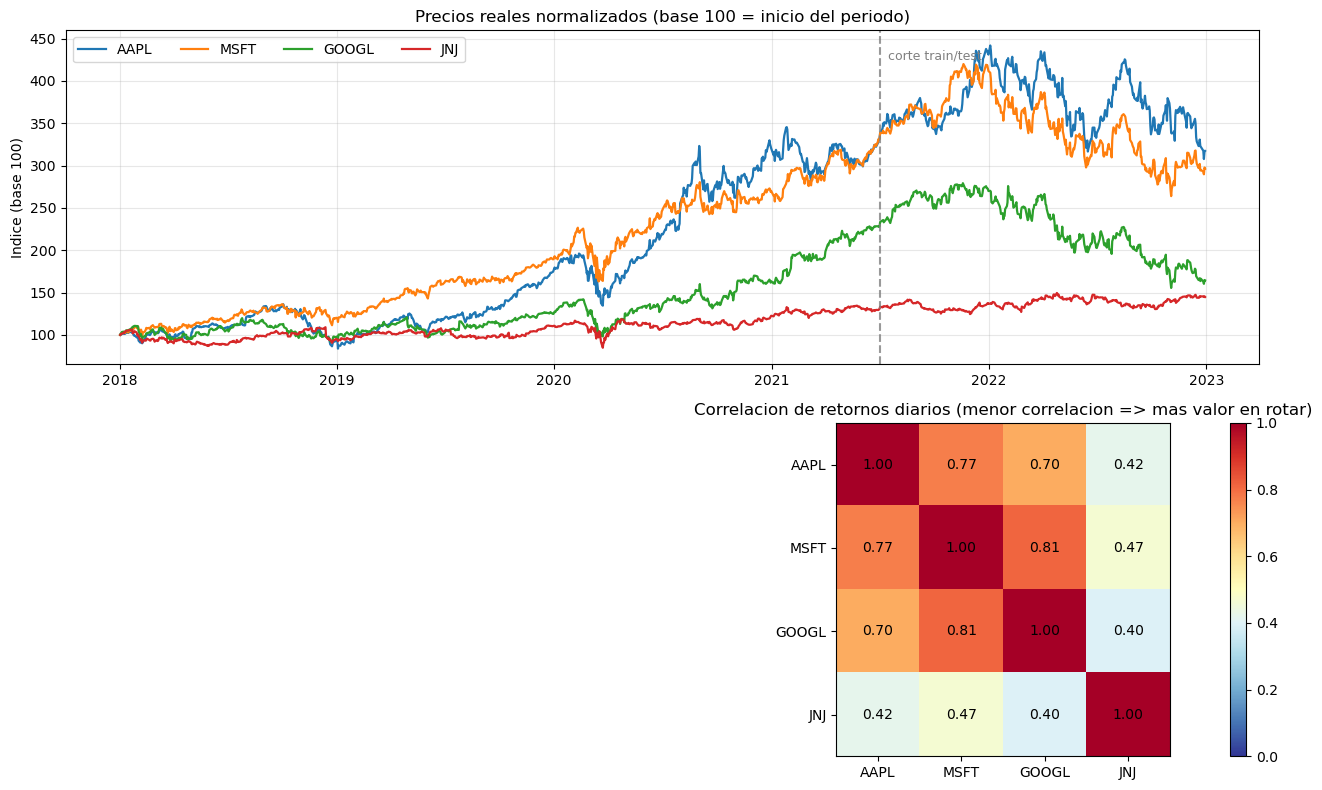

In [4]:
# Matriz de precios: filas = tiempo, columnas = activos
precios = precios_df.values.astype(np.float32)
N_ACTIVOS = precios.shape[1]

# Separacion train / test SIN fuga de datos (data leakage):
# el agente se entrena solo con el pasado y se evalua en un tramo NUNCA visto.
n_train = int(len(precios) * 0.7)
precios_train = precios[:n_train]
precios_test  = precios[n_train:]

fecha_corte = precios_df.index[n_train]
print(f"Activos: {TICKERS}  (N = {N_ACTIVOS})")
print(f"Train: {len(precios_train)} barras (hasta {fecha_corte.date()})")
print(f"Test : {len(precios_test)} barras (desde {fecha_corte.date()}, NO visto)")

# --- Grafica 1: precios normalizados (base 100) para poder compararlos en un mismo eje ---
fig, axes = plt.subplots(2, 1, figsize=(13, 8))

norm = precios_df / precios_df.iloc[0] * 100
for t in TICKERS:
    axes[0].plot(precios_df.index, norm[t], label=t, lw=1.6)
axes[0].axvline(fecha_corte, color="gray", linestyle="--", alpha=0.8)
axes[0].text(fecha_corte, axes[0].get_ylim()[1]*0.95, "  corte train/test",
             color="gray", fontsize=9, va="top")
axes[0].set_title("Precios reales normalizados (base 100 = inicio del periodo)")
axes[0].set_ylabel("Indice (base 100)")
axes[0].legend(ncol=len(TICKERS)); axes[0].grid(alpha=0.3)

# --- Grafica 2: matriz de correlacion de retornos diarios ---
# Si los activos estuvieran perfectamente correlacionados, rotar entre ellos no aportaria nada.
rets = precios_df.pct_change().dropna()
corr = rets.corr()
im = axes[1].imshow(corr.values, cmap="RdYlBu_r", vmin=0, vmax=1)
axes[1].set_xticks(range(N_ACTIVOS)); axes[1].set_xticklabels(TICKERS)
axes[1].set_yticks(range(N_ACTIVOS)); axes[1].set_yticklabels(TICKERS)
for i in range(N_ACTIVOS):
    for j in range(N_ACTIVOS):
        axes[1].text(j, i, f"{corr.values[i,j]:.2f}", ha="center", va="center", fontsize=10)
axes[1].set_title("Correlacion de retornos diarios (menor correlacion => mas valor en rotar)")
plt.colorbar(im, ax=axes[1], fraction=0.025)

plt.tight_layout(); plt.show()

## 3. El ambiente de portafolio (el MDP)

Traducimos el problema al lenguaje de un **Proceso de Decisión de Markov**:
$\mathcal{M} = \langle \mathcal{S}, \mathcal{A}, P, R, \gamma \rangle$.

### 3.1 Estado $s_t$ — *¿qué observa el agente?*

El estado concatena, para **cada** activo, los retornos relativos de las últimas `ventana` barras,
más la posición actual codificada en *one-hot*:

$$s_t = \big[\underbrace{r^{(1)}_{t-w:t}, \dots, r^{(N)}_{t-w:t}}_{N \times w},\ \underbrace{\text{one-hot}(\text{posición})}_{N+1},\ \underbrace{v_t / v_0}_{1}\big]$$

Dos decisiones de diseño heredadas de la versión anterior y del material de clase:

- **Retornos relativos, no precios absolutos** (Lapan, Cap. 10): permite al agente generalizar
  patrones sin importar si la acción vale \$40 o \$400. Esto es *especialmente* importante aquí,
  porque los 4 activos tienen niveles de precio muy distintos.
- **La posición forma parte del estado**: sin ella el MDP no sería markoviano — el agente no
  podría saber si rotar implica pagar comisión.

Dimensión total: $N \times w + (N+1) + 1$. Con $N=4$, $w=10$: $40 + 5 + 1 = 46$.

### 3.2 Acciones $\mathcal{A}$

$$a_t \in \{0, 1, \dots, N\}, \qquad
a_t = 0 \Rightarrow \text{todo en efectivo}, \qquad
a_t = i \Rightarrow \text{todo en el activo } i$$

Con $N=4$ son **5 acciones discretas** — perfectamente manejable para DQN.

### 3.3 Recompensa $r_t$

$$r_t = \frac{v_{t+1} - v_t}{v_t} \times 100 - \text{costo de rotación}$$

Usamos el **cambio porcentual** del valor del portafolio, no el cambio absoluto. Esto mantiene la
escala de la recompensa estable e independiente del capital inicial, lo que ayuda a la convergencia
de la red (una recompensa en dólares crecería a medida que crece el portafolio, desestabilizando
el aprendizaje).

**Costo de transacción:** rotar de un activo a otro cuesta comisión (0.1%, como en Lapan Cap. 10).
Esto es esencial: sin costos, el agente aprendería a rotar frenéticamente todos los días, algo
irrealizable en la práctica.

### 3.4 ⚠️ Retardo de ejecución: evitando un *look-ahead* sutil

Este punto es **crítico** y fue un error real detectado al construir este notebook.

En una primera versión, `step()` rotaba la posición **y luego** revaluaba el portafolio con los
precios de la barra siguiente. El efecto: el agente elegía activo y *acto seguido* cobraba el
movimiento de ese mismo periodo — es decir, decidía "sabiendo" cómo se movería el precio.

El síntoma fue inconfundible: el valor del portafolio en entrenamiento crecía de \$1.000 a más de
\$127.000 (≈ +12.600%), un resultado imposible en un mercado real. **Una curva de entrenamiento
demasiado buena casi siempre indica fuga de información, no un buen agente.**

La versión corregida devenga el retorno de la barra con la posición **que ya se traía**, y solo
después aplica la decisión nueva, que surte efecto desde la barra siguiente:

$$v_{t+1} = v_t \cdot \frac{p_{t+1}^{(\text{pos}_t)}}{p_t^{(\text{pos}_t)}}
\quad\text{y solo entonces}\quad \text{pos}_{t+1} \leftarrow a_t$$

Esto refleja la realidad operativa (una orden se ejecuta después de decidirla) y elimina la fuga.

### 3.5 Terminación

El episodio termina al llegar al final de la serie (`terminated`). No usamos `truncated`, pero
mantenemos la distinción conceptual de la API de Gymnasium.

In [5]:
class PortafolioEnv:
    '''
    Ambiente de asignacion de portafolio multi-activo (interfaz estilo Gymnasium).

    Accion 0        -> mantener todo el capital en EFECTIVO
    Accion i (1..N) -> mantener todo el capital en el activo (i-1)

    En cada paso el capital esta 100% en una sola posicion. Rotar de una posicion a otra
    paga comision sobre el valor rotado.
    '''
    def __init__(self, precios, ventana=10, comision=0.001, capital_inicial=1000.0):
        assert precios.ndim == 2, "precios debe ser matriz [tiempo, activos]"
        self.precios = precios
        self.n_activos = precios.shape[1]
        self.ventana = ventana
        self.comision = comision
        self.capital_inicial = capital_inicial

        self.n_acciones = self.n_activos + 1                    # efectivo + un activo cada uno
        self.dim_estado = self.n_activos * ventana + (self.n_activos + 1) + 1
        self.reset()

    def reset(self):
        '''Reinicia el episodio al inicio de la serie.'''
        self.t = self.ventana
        self.posicion = 0            # 0 = efectivo; i = activo i-1
        self.valor = self.capital_inicial
        self.n_rotaciones = 0
        return self._get_state()

    def _get_state(self):
        '''Construye el vector de estado s_t.'''
        bloques = []
        for j in range(self.n_activos):
            ventana_precios = self.precios[self.t - self.ventana:self.t, j]
            # retornos relativos (p_{i+1}-p_i)/p_i -> patron independiente del nivel de precio
            retornos = np.diff(ventana_precios) / ventana_precios[:-1]
            retornos = np.append(retornos, 0.0)      # padding: conserva la dimension `ventana`
            bloques.append(retornos)

        # Posicion actual en one-hot: el agente debe saber donde esta parado
        one_hot = np.zeros(self.n_acciones, dtype=np.float64)
        one_hot[self.posicion] = 1.0

        fraccion = self.valor / self.capital_inicial
        estado = np.concatenate(bloques + [one_hot, [fraccion]])
        return estado.astype(np.float32)

    def step(self, accion):
        '''Ejecuta la accion y avanza una barra temporal.'''
        assert 0 <= accion < self.n_acciones

        valor_previo = self.valor

        # 1) El retorno de ESTA barra se devenga con la posicion que ya se traia,
        #    ANTES de aplicar la decision nueva. Esto evita un look-ahead sutil:
        #    si rotaramos y revaluaramos en el mismo paso, el agente estaria eligiendo
        #    el activo sabiendo ya como se mueve hoy (informacion no disponible en la
        #    practica). La orden se ejecuta con un retardo de una barra, como en la realidad.
        p_ahora = self.precios[self.t]
        p_sig   = self.precios[self.t + 1]
        if self.posicion > 0:                        # invertido en un activo
            j = self.posicion - 1
            self.valor *= p_sig[j] / p_ahora[j]
        # si posicion == 0 (efectivo) el valor no cambia

        # 2) Recien ahora se aplica la decision: rotar cuesta comision y surte
        #    efecto a partir de la barra siguiente.
        if accion != self.posicion:
            self.valor *= (1.0 - self.comision)
            self.posicion = accion
            self.n_rotaciones += 1

        self.t += 1

        # 3) Recompensa: cambio PORCENTUAL del portafolio (escala estable)
        recompensa = (self.valor - valor_previo) / valor_previo * 100.0

        # 4) Terminacion: se acabo la serie (necesitamos t+1 valido en el proximo step)
        terminated = (self.t >= len(self.precios) - 1)
        done = terminated

        info = {"valor": self.valor, "posicion": self.posicion,
                "rotaciones": self.n_rotaciones}
        estado = self._get_state() if not done else np.zeros(self.dim_estado, dtype=np.float32)
        return estado, recompensa, done, info


# Verificacion rapida del ambiente
env_prueba = PortafolioEnv(precios_train)
s0 = env_prueba.reset()
print(f"Dimension del estado : {env_prueba.dim_estado}  (esperado {N_ACTIVOS}*10 + {N_ACTIVOS+1} + 1)")
print(f"Numero de acciones   : {env_prueba.n_acciones}  -> [efectivo] + {TICKERS}")
print(f"Forma de s0          : {s0.shape}")
s1, r1, d1, i1 = env_prueba.step(1)   # comprar el primer activo
print(f"Tras step(1): recompensa={r1:.4f}  valor={i1['valor']:.2f}  posicion={i1['posicion']}")

Dimension del estado : 46  (esperado 4*10 + 5 + 1)
Numero de acciones   : 5  -> [efectivo] + ['AAPL', 'MSFT', 'GOOGL', 'JNJ']
Forma de s0          : (46,)
Tras step(1): recompensa=-0.1000  valor=999.00  posicion=1


## 4. La red Q (red *online*)

Reemplazamos la tabla Q por una **red neuronal** $Q(s,a;\theta)$, como explica el material:
*"DQN es Q-learning donde la función $Q(s,a)$ se aproxima con una red neuronal profunda"*.

**Arquitectura** (siguiendo la lámina "Arquitectura típica de una red Q"):
- **Entrada:** el vector de estado (dimensión 46 en nuestra configuración).
- **Dos capas ocultas** de 128 neuronas con ReLU.
- **Salida:** $N+1 = 5$ valores, un $Q(s,a)$ por cada acción posible.

Una sola pasada entrega el Q de las 5 acciones a la vez, y la acción *greedy* es
$a^* = \arg\max_a Q(s,a;\theta)$.

> **Nota:** aquí se ve por qué la formulación importa. La red solo creció de 3 a 5 salidas al
> pasar de 1 activo a un portafolio de 4. Con la formulación `hold/buy/sell` por activo habrían
> sido $3^4 = 81$ salidas.

In [6]:
class QNetwork(nn.Module):
    def __init__(self, dim_estado, n_acciones, hidden=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(dim_estado, hidden), nn.ReLU(),   # entrada -> oculta 1
            nn.Linear(hidden, hidden),     nn.ReLU(),   # oculta 1 -> oculta 2
            nn.Linear(hidden, n_acciones),              # salida: un Q por accion
            # Sin activacion final: Q(s,a) puede ser cualquier real.
        )

    def forward(self, x):
        return self.net(x)


_net = QNetwork(env_prueba.dim_estado, env_prueba.n_acciones)
_out = _net(torch.zeros(1, env_prueba.dim_estado))
print("Forma de salida de la red Q:", _out.shape, f"(esperado: [1, {env_prueba.n_acciones}])")
print("Parametros entrenables:", sum(p.numel() for p in _net.parameters()))

Forma de salida de la red Q: torch.Size([1, 5]) (esperado: [1, 5])
Parametros entrenables: 23173


## 5. Replay buffer (memoria de experiencias)

El *replay buffer* almacena transiciones $(s, a, r, s', done)$ y permite muestrear **mini-lotes
aleatorios**. Como vimos en clase, esto:
- **rompe la correlación temporal** entre muestras consecutivas (que violaría el supuesto i.i.d.),
- **reutiliza** experiencia pasada (eficiencia de datos),
- **estabiliza** el entrenamiento.

> *Analogía de la clase:* "el agente no aprende solo de lo último que le pasó; repasa experiencias
> antiguas mezcladas".

In [7]:
class ReplayBuffer:
    def __init__(self, capacidad):
        self.buffer = deque(maxlen=capacidad)   # descarta las mas viejas (FIFO)

    def add(self, s, a, r, s2, done):
        self.buffer.append((s, a, r, s2, done))

    def sample(self, batch_size):
        # random.sample -> muestreo ALEATORIO: esto rompe la correlacion temporal
        batch = random.sample(self.buffer, batch_size)
        s, a, r, s2, d = zip(*batch)
        return (np.array(s, dtype=np.float32), np.array(a, dtype=np.int64),
                np.array(r, dtype=np.float32), np.array(s2, dtype=np.float32),
                np.array(d, dtype=np.float32))

    def __len__(self):
        return len(self.buffer)

print("ReplayBuffer definido.")

ReplayBuffer definido.


## 6. El agente DQN: red objetivo, pérdida TD y ε-greedy

### 6.1 Red objetivo (*target network*)
DQN usa **dos redes**: la *online* ($\theta$, se entrena cada paso) y la *objetivo* ($\theta^-$,
congelada y sincronizada cada $C$ pasos). Esto resuelve el problema del **"blanco móvil"**.

### 6.2 Pérdida TD
Para cada transición $(s,a,r,s',done)$:

$$y = \begin{cases} r & \text{si } done=1 \\ r + \gamma \max_{a'} Q_{target}(s',a';\theta^-) & \text{si } done=0 \end{cases}$$

$$\mathcal{L}(\theta) = \big(y - Q_{online}(s,a;\theta)\big)^2$$

El término `(1 - done)` anula el futuro cuando el estado es terminal.

### 6.3 Exploración ε-greedy
Con probabilidad $\varepsilon$ el agente explora; con $1-\varepsilon$ explota. $\varepsilon$
arranca alto y decae.

> **Ajuste respecto a la versión de un activo:** aquí usamos **Huber loss** (`smooth_l1_loss`) en
> vez de MSE. Con datos reales aparecen días de movimientos extremos (*outliers*) que con MSE
> producirían gradientes enormes y desestabilizarían el entrenamiento. Huber se comporta como MSE
> cerca de cero y como error absoluto lejos, acotando el impacto de esos días. Es la misma elección
> que hace el paper original de DQN (Mnih et al., 2015).

In [8]:
class DQNAgent:
    def __init__(self, dim_estado, n_acciones, lr=1e-3, gamma=0.99, device=DEVICE):
        self.device = device
        self.gamma = gamma
        self.n_acciones = n_acciones
        # Red online (se entrena) y red objetivo (congelada, copia inicial)
        self.online = QNetwork(dim_estado, n_acciones).to(device)
        self.target = copy.deepcopy(self.online).to(device)
        self.target.eval()
        self.opt = torch.optim.Adam(self.online.parameters(), lr=lr)

    def elegir_accion(self, estado, epsilon):
        '''Politica epsilon-greedy.'''
        if random.random() < epsilon:
            return random.randrange(self.n_acciones)          # EXPLORAR
        with torch.no_grad():
            s = torch.tensor(estado, dtype=torch.float32, device=self.device).unsqueeze(0)
            return self.online(s).argmax(dim=1).item()        # EXPLOTAR

    def entrenar_paso(self, buffer, batch_size):
        '''Un paso de descenso de gradiente sobre un mini-lote (perdida TD).'''
        if len(buffer) < batch_size:
            return None
        s, a, r, s2, d = buffer.sample(batch_size)
        s  = torch.tensor(s,  device=self.device)
        a  = torch.tensor(a,  device=self.device)
        r  = torch.tensor(r,  device=self.device)
        s2 = torch.tensor(s2, device=self.device)
        d  = torch.tensor(d,  device=self.device)

        # Q(s,a) predicho por la red ONLINE, solo para la accion efectivamente tomada
        q_sa = self.online(s).gather(1, a.unsqueeze(1)).squeeze(1)

        # Target y = r + gamma * max_a' Q_target(s',a') * (1 - done)
        with torch.no_grad():
            q_next = self.target(s2).max(dim=1)[0]
            y = r + self.gamma * q_next * (1.0 - d)

        # Huber loss: robusta a los outliers de los datos reales
        loss = F.smooth_l1_loss(q_sa, y)

        self.opt.zero_grad()
        loss.backward()
        # Clipping de gradiente: red de seguridad extra contra pasos destructivos
        nn.utils.clip_grad_norm_(self.online.parameters(), max_norm=10.0)
        self.opt.step()
        return loss.item()

    def sincronizar_target(self):
        '''theta^- <- theta (cada C pasos).'''
        self.target.load_state_dict(self.online.state_dict())

print("DQNAgent definido.")

DQNAgent definido.


## 7. Bucle de entrenamiento

Traducción directa del **pseudocódigo de DQN** de la clase: inicializar redes y buffer → por cada
episodio, elegir acción ε-greedy, ejecutar, guardar en el buffer, muestrear mini-lote, calcular
target con la red objetivo, minimizar la pérdida TD, sincronizar la red objetivo cada $C$ pasos,
y decaer $\varepsilon$.

In [9]:
# ---- Hiperparametros ----
GAMMA = 0.99            # factor de descuento
LR = 1e-3               # tasa de aprendizaje
BUFFER_CAP = 20_000
BATCH_SIZE = 64
MIN_BUFFER = 500        # no entrenar hasta tener suficientes muestras
TARGET_SYNC = 200       # cada C pasos: theta^- <- theta
EPISODIOS = 100
EPS_START, EPS_MIN, EPS_DECAY = 1.0, 0.05, 0.97

env = PortafolioEnv(precios_train)
agente = DQNAgent(env.dim_estado, env.n_acciones, lr=LR, gamma=GAMMA)
buffer = ReplayBuffer(BUFFER_CAP)

hist_valor, hist_recompensa, hist_loss, hist_rot = [], [], [], []
epsilon = EPS_START
step_global = 0

print(f"Entrenando {EPISODIOS} episodios sobre {len(precios_train)} barras...")
print(f"Estado: {env.dim_estado}D | Acciones: {env.n_acciones}\n")

for ep in range(1, EPISODIOS + 1):
    s = env.reset()
    done = False
    R_ep = 0.0
    losses_ep = []
    while not done:
        a = agente.elegir_accion(s, epsilon)
        s2, r, done, info = env.step(a)
        buffer.add(s, a, r, s2, float(done))
        s = s2
        R_ep += r
        step_global += 1
        if len(buffer) >= MIN_BUFFER:
            loss = agente.entrenar_paso(buffer, BATCH_SIZE)
            if loss is not None:
                losses_ep.append(loss)
            if step_global % TARGET_SYNC == 0:
                agente.sincronizar_target()
    epsilon = max(EPS_MIN, epsilon * EPS_DECAY)
    hist_valor.append(info["valor"])
    hist_recompensa.append(R_ep)
    hist_loss.append(np.mean(losses_ep) if losses_ep else 0.0)
    hist_rot.append(info["rotaciones"])
    if ep % 10 == 0:
        print(f"Ep {ep:3d} | valor: {info['valor']:8.2f} | recompensa: {R_ep:7.2f} "
              f"| rotaciones: {info['rotaciones']:4d} | eps: {epsilon:.3f}")

print("\nEntrenamiento terminado.")

Entrenando 100 episodios sobre 881 barras...
Estado: 46D | Acciones: 5

Ep  10 | valor:  1178.00 | recompensa:   27.69 | rotaciones:  684 | eps: 0.737
Ep  20 | valor:  1665.60 | recompensa:   64.22 | rotaciones:  655 | eps: 0.544
Ep  30 | valor:  3656.26 | recompensa:  143.48 | rotaciones:  593 | eps: 0.401
Ep  40 | valor:  4570.73 | recompensa:  163.61 | rotaciones:  581 | eps: 0.296
Ep  50 | valor:  7771.40 | recompensa:  220.79 | rotaciones:  516 | eps: 0.218
Ep  60 | valor: 14830.21 | recompensa:  282.73 | rotaciones:  512 | eps: 0.161
Ep  70 | valor: 21293.67 | recompensa:  318.84 | rotaciones:  519 | eps: 0.119
Ep  80 | valor: 27351.05 | recompensa:  345.03 | rotaciones:  401 | eps: 0.087
Ep  90 | valor: 40267.55 | recompensa:  383.09 | rotaciones:  521 | eps: 0.064
Ep 100 | valor: 22951.60 | recompensa:  328.47 | rotaciones:  450 | eps: 0.050

Entrenamiento terminado.


## 8. Gráficas de entrenamiento

Monitoreamos recompensa, valor final del portafolio, pérdida TD y **número de rotaciones**.

Esta última es nueva respecto a la versión de un activo y es diagnóstica: si el agente rota
cientos de veces por episodio, está quemando capital en comisiones; si rota 0 veces, degeneró a
una estrategia pasiva. Lo sano es que **baje y se estabilice** en un número moderado a medida que
aprende que rotar cuesta.

Como advierte la clase, la curva de DQN **no es monótona**; buscamos una **tendencia**.

> **Atención:** el valor del portafolio en entrenamiento alcanzará cifras absurdamente altas.
> Eso **no** significa que el agente sea bueno — es sobreajuste. Se analiza a fondo en la
> sección 9.1, una vez definidos los baselines para poder comparar.

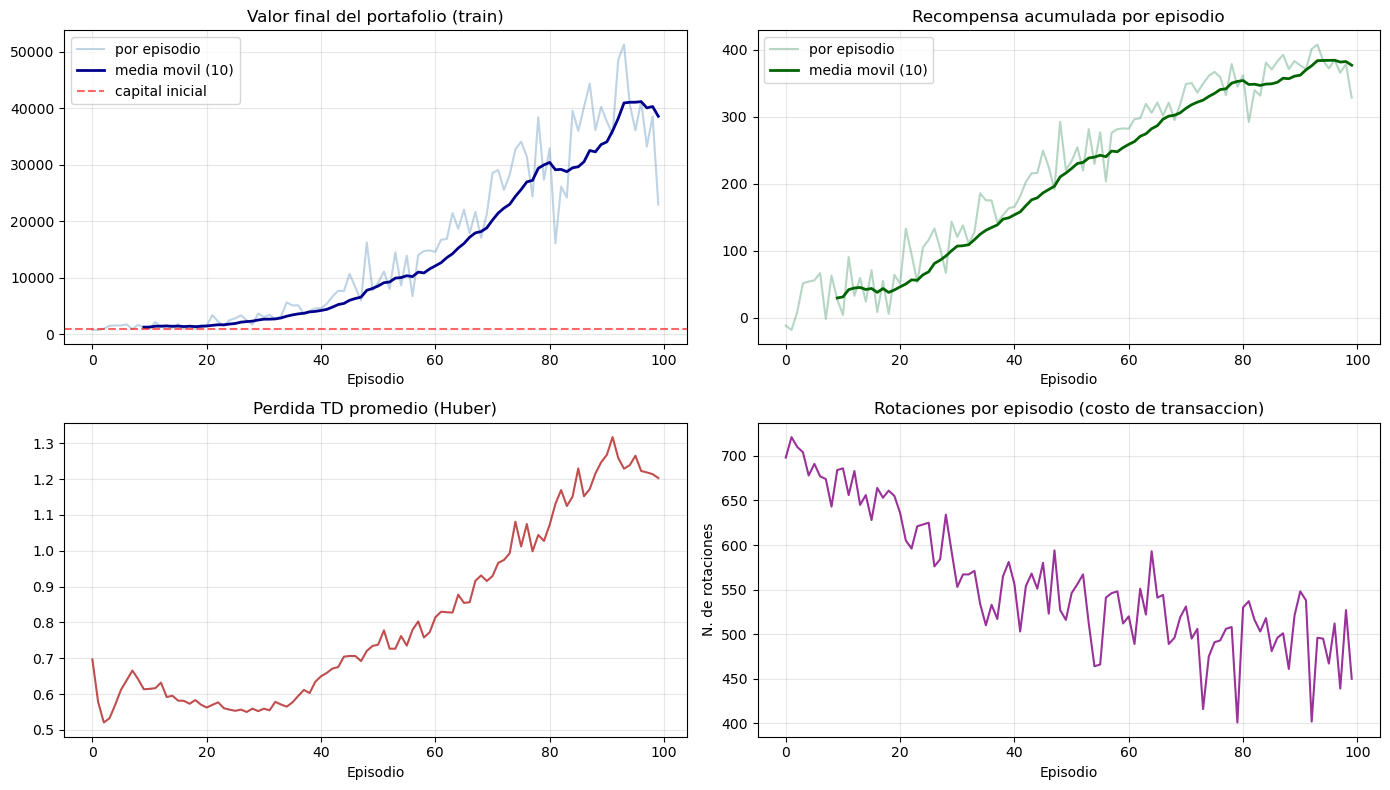

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

def media_movil(x, w=10):
    return np.convolve(x, np.ones(w)/w, mode="valid")

ax = axes[0, 0]
ax.plot(hist_valor, alpha=0.35, color="steelblue", label="por episodio")
ax.plot(range(9, len(hist_valor)), media_movil(hist_valor), color="darkblue", lw=2, label="media movil (10)")
ax.axhline(1000, color="red", linestyle="--", alpha=0.6, label="capital inicial")
ax.set_title("Valor final del portafolio (train)"); ax.set_xlabel("Episodio")
ax.legend(); ax.grid(alpha=0.3)

ax = axes[0, 1]
ax.plot(hist_recompensa, alpha=0.35, color="seagreen", label="por episodio")
ax.plot(range(9, len(hist_recompensa)), media_movil(hist_recompensa), color="darkgreen", lw=2, label="media movil (10)")
ax.set_title("Recompensa acumulada por episodio"); ax.set_xlabel("Episodio")
ax.legend(); ax.grid(alpha=0.3)

ax = axes[1, 0]
ax.plot(hist_loss, color="firebrick", alpha=0.8)
ax.set_title("Perdida TD promedio (Huber)"); ax.set_xlabel("Episodio"); ax.grid(alpha=0.3)

ax = axes[1, 1]
ax.plot(hist_rot, color="purple", alpha=0.8)
ax.set_title("Rotaciones por episodio (costo de transaccion)")
ax.set_xlabel("Episodio"); ax.set_ylabel("N. de rotaciones"); ax.grid(alpha=0.3)

plt.tight_layout(); plt.show()

## 9. Evaluación en datos NO vistos, contra *baselines* honestos

> Esta sección mide **cuánto rinde** la política aprendida. La siguiente (§10) responde una
> pregunta distinta y más importante: **¿ese número es creíble?**

Evaluamos con $\varepsilon = 0$ (política puramente *greedy*) sobre el tramo de **test**.

> Esta separación train/test evita la **fuga de datos** (*data leakage*) que advierte Sanghi
> (Cap. 13): si el agente "viera el futuro", los resultados serían engañosamente buenos.

### Los baselines

Comparar solo contra "no hacer nada" sería autocomplaciente. Usamos cuatro referencias:

| Baseline | Qué representa |
|---|---|
| **Buy & Hold de cada activo** | ¿Le habría ido mejor al inversionista comprando *un* activo y olvidándose? |
| **Portafolio equiponderado (1/N)** | 25% en cada activo. Es el baseline **serio**: capta la diversificación sin ninguna inteligencia. Difícil de batir. |
| **Mejor activo individual** | El techo de "haber elegido bien" con información perfecta *a posteriori*. |
| **Agente aleatorio** | Rota al azar. Mide si el DQN aprendió *algo* por encima del ruido. |

Además del retorno, reportamos métricas **ajustadas por riesgo**, porque un retorno alto obtenido
con volatilidad extrema no es una buena estrategia:

- **Sharpe ratio** (anualizado): retorno por unidad de volatilidad.
- **Máximo drawdown**: la peor caída pico-a-valle. Mide el dolor que habría sufrido el inversionista.

In [11]:
def evaluar(agente, precios_eval, epsilon=0.0):
    '''Corre el agente en modo greedy y registra su trayectoria de decisiones.'''
    env_eval = PortafolioEnv(precios_eval)
    s = env_eval.reset()
    done = False
    valores, acciones = [], []
    while not done:
        a = agente.elegir_accion(s, epsilon=epsilon)
        s, r, done, info = env_eval.step(a)
        valores.append(info["valor"])
        acciones.append(a)
    return np.array(valores), np.array(acciones), env_eval


def metricas(serie_valores, periodos_por_anio=252):
    '''Retorno total, Sharpe anualizado y maximo drawdown de una curva de capital.'''
    v = np.asarray(serie_valores, dtype=np.float64)
    ret_total = (v[-1] / v[0] - 1.0) * 100.0
    rets = np.diff(v) / v[:-1]
    if rets.std() > 1e-12:
        sharpe = rets.mean() / rets.std() * np.sqrt(periodos_por_anio)
    else:
        sharpe = 0.0
    pico = np.maximum.accumulate(v)
    max_dd = ((v - pico) / pico).min() * 100.0
    return ret_total, sharpe, max_dd


CAPITAL = 1000.0
V = 10  # = ventana, punto de arranque comun para todas las curvas

# --- Agente DQN (greedy) ---
valores_dqn, acciones_dqn, env_eval = evaluar(agente, precios_test)

# --- Baseline: Buy & Hold de cada activo ---
buy_hold = {}
for j, tk in enumerate(TICKERS):
    serie = precios_test[V:, j]
    buy_hold[tk] = CAPITAL * serie / serie[0]

# --- Baseline: portafolio equiponderado 1/N (sin rebalanceo) ---
tramo = precios_test[V:, :]
equi = CAPITAL * (tramo / tramo[0]).mean(axis=1)

# --- Baseline: agente aleatorio (promedio de 20 corridas para no depender de la suerte) ---
rng_eval = np.random.default_rng(SEED)
corridas_azar = []
for _ in range(20):
    env_r = PortafolioEnv(precios_test)
    s = env_r.reset(); done = False; vals = []
    while not done:
        s, r, done, info = env_r.step(int(rng_eval.integers(env_r.n_acciones)))
        vals.append(info["valor"])
    corridas_azar.append(vals)
azar = np.mean(np.array(corridas_azar), axis=0)

# --- Tabla comparativa ---
filas = []
filas.append(("DQN (greedy)",) + metricas(valores_dqn))
filas.append(("Equiponderado 1/N",) + metricas(equi))
for tk in TICKERS:
    filas.append((f"Buy&Hold {tk}",) + metricas(buy_hold[tk]))
filas.append(("Aleatorio (prom. 20)",) + metricas(azar))

tabla = pd.DataFrame(filas, columns=["Estrategia", "Retorno %", "Sharpe", "Max DD %"])
tabla = tabla.set_index("Estrategia").round(2)

print("=== RESULTADOS EN TEST (datos NO vistos) ===")
print(f"Periodo de test: {precios_df.index[n_train+V].date()} -> {precios_df.index[-1].date()}")
print(f"Barras: {len(valores_dqn)} | Rotaciones del DQN: {env_eval.n_rotaciones}\n")
print(tabla.to_string())

mejor_bh = max(TICKERS, key=lambda t: buy_hold[t][-1])
print(f"\nMejor activo individual (a posteriori): {mejor_bh}")
print(f"DQN vs equiponderado : {metricas(valores_dqn)[0] - metricas(equi)[0]:+.2f} puntos porcentuales")
print(f"DQN vs mejor activo  : {metricas(valores_dqn)[0] - metricas(buy_hold[mejor_bh])[0]:+.2f} puntos porcentuales")

=== RESULTADOS EN TEST (datos NO vistos) ===
Periodo de test: 2021-07-19 -> 2022-12-30
Barras: 367 | Rotaciones del DQN: 271

                      Retorno %  Sharpe  Max DD %
Estrategia                                       
DQN (greedy)              -7.52   -0.13    -23.48
Equiponderado 1/N         -9.86   -0.18    -26.19
Buy&Hold AAPL             -7.99   -0.02    -30.35
Buy&Hold MSFT            -12.29   -0.13    -37.15
Buy&Hold GOOGL           -29.18   -0.52    -44.32
Buy&Hold JNJ              10.00    0.48    -12.74
Aleatorio (prom. 20)     -33.56   -1.33    -36.74

Mejor activo individual (a posteriori): JNJ
DQN vs equiponderado : +2.34 puntos porcentuales
DQN vs mejor activo  : -17.52 puntos porcentuales


### 9.1 Visualización de las decisiones del agente

Tres vistas:
1. **Curvas de capital**: DQN contra todos los baselines.
2. **Mapa de posiciones**: en qué activo estuvo el agente en cada momento — permite ver si rota
   con criterio o erráticamente.
3. **Distribución de posiciones**: cuánto tiempo pasó en cada activo.

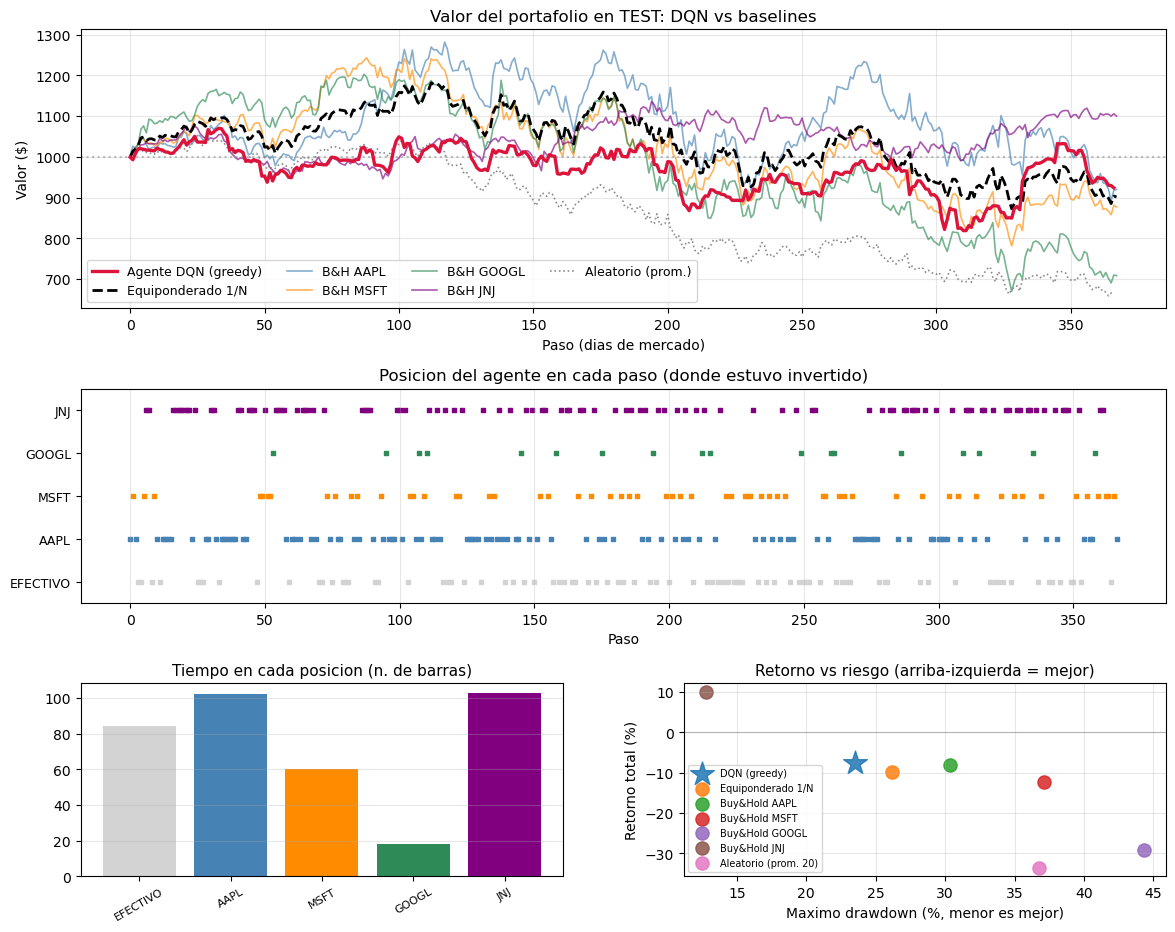

Distribucion de posiciones del DQN en test:
  EFECTIVO  :   84 barras ( 22.9%)
  AAPL      :  102 barras ( 27.8%)
  MSFT      :   60 barras ( 16.3%)
  GOOGL     :   18 barras (  4.9%)
  JNJ       :  103 barras ( 28.1%)

Rotaciones totales: 271 (costo aprox. acumulado: 27.1% del capital)


In [12]:
fig = plt.figure(figsize=(14, 11))
gs = fig.add_gridspec(3, 2, height_ratios=[1.3, 1.0, 0.9], hspace=0.35, wspace=0.25)

# --- (1) Curvas de capital ---
ax = fig.add_subplot(gs[0, :])
ax.plot(valores_dqn, label="Agente DQN (greedy)", color="crimson", lw=2.4, zorder=5)
ax.plot(equi, label="Equiponderado 1/N", color="black", lw=2.0, linestyle="--", zorder=4)
for tk, col in zip(TICKERS, ["steelblue", "darkorange", "seagreen", "purple"]):
    ax.plot(buy_hold[tk], label=f"B&H {tk}", color=col, lw=1.2, alpha=0.65)
ax.plot(azar, label="Aleatorio (prom.)", color="gray", lw=1.2, linestyle=":", alpha=0.9)
ax.axhline(CAPITAL, color="gray", alpha=0.5, linestyle=":")
ax.set_title("Valor del portafolio en TEST: DQN vs baselines", fontsize=12)
ax.set_xlabel("Paso (dias de mercado)"); ax.set_ylabel("Valor ($)")
ax.legend(ncol=4, fontsize=9); ax.grid(alpha=0.3)

# --- (2) Mapa de posiciones en el tiempo ---
ax = fig.add_subplot(gs[1, :])
etiquetas = ["EFECTIVO"] + TICKERS
colores = ["lightgray", "steelblue", "darkorange", "seagreen", "purple"]
for k in range(len(etiquetas)):
    idx = np.where(acciones_dqn == k)[0]
    if len(idx) > 0:
        ax.scatter(idx, np.full(len(idx), k), color=colores[k], s=8, marker="s")
ax.set_yticks(range(len(etiquetas))); ax.set_yticklabels(etiquetas, fontsize=9)
ax.set_title("Posicion del agente en cada paso (donde estuvo invertido)", fontsize=12)
ax.set_xlabel("Paso"); ax.grid(alpha=0.3, axis="x")
ax.set_ylim(-0.5, len(etiquetas) - 0.5)

# --- (3) Distribucion de posiciones ---
ax = fig.add_subplot(gs[2, 0])
conteo = collections.Counter(acciones_dqn.tolist())
vals = [conteo.get(k, 0) for k in range(len(etiquetas))]
ax.bar(etiquetas, vals, color=colores)
ax.set_title("Tiempo en cada posicion (n. de barras)", fontsize=11)
ax.tick_params(axis="x", rotation=30, labelsize=8); ax.grid(alpha=0.3, axis="y")

# --- (4) Retorno vs riesgo ---
ax = fig.add_subplot(gs[2, 1])
for nombre, fila in tabla.iterrows():
    marcador = "*" if nombre.startswith("DQN") else "o"
    tam = 320 if nombre.startswith("DQN") else 90
    ax.scatter(abs(fila["Max DD %"]), fila["Retorno %"], s=tam, marker=marcador,
               label=nombre, alpha=0.85)
ax.set_xlabel("Maximo drawdown (%, menor es mejor)"); ax.set_ylabel("Retorno total (%)")
ax.set_title("Retorno vs riesgo (arriba-izquierda = mejor)", fontsize=11)
ax.axhline(0, color="gray", lw=0.8, alpha=0.5)
ax.legend(fontsize=7, loc="best"); ax.grid(alpha=0.3)

plt.show()

print("Distribucion de posiciones del DQN en test:")
total = len(acciones_dqn)
for k, et in enumerate(etiquetas):
    c = conteo.get(k, 0)
    print(f"  {et:10s}: {c:4d} barras ({c/total*100:5.1f}%)")
print(f"\nRotaciones totales: {env_eval.n_rotaciones} "
      f"(costo aprox. acumulado: {env_eval.n_rotaciones * 0.1:.1f}% del capital)")

## 10. ⚠️ ¿Es creíble ese resultado? — Los dos diagnósticos

Esta es la sección más importante del trabajo.

La sección anterior entregó **un número**: el retorno de la política en test. Pero un número aislado
no dice nada por sí solo. Antes de interpretarlo hay que responder dos preguntas incómodas:

| Pregunta | Riesgo si no se responde | Diagnóstico |
|---|---|---|
| ¿El agente **aprendió** o **memorizó**? | Reportar como aprendizaje lo que es memoria del tramo de entrenamiento | §10.1 — brecha train/test |
| ¿El resultado es **del método** o **de la semilla**? | Reportar una corrida afortunada como si fuera capacidad del algoritmo | §10.2 — multi-semilla |

Ambos diagnósticos son controles de honestidad metodológica. Sin ellos, cualquier conclusión sobre
el desempeño del agente sería infundada — y como se verá, ambos revelan problemas serios.

### 10.1 Primer diagnóstico: ¿aprendizaje o memorización?

La curva de entrenamiento anterior crece hasta valores enormes (del orden de \$50.000 partiendo de
\$1.000, es decir **+5.000%** en ~3,5 años). **Ningún agente de trading real logra eso.** Antes de
celebrar, hay que preguntarse de dónde sale ese número.

La causa es **sobreajuste por repetición**: entrenamos 100 episodios sobre **exactamente el mismo
tramo histórico**. El agente no necesita descubrir una regla general; le basta con *memorizar* qué
activo subió cada día concreto de 2018-2021. Con 23.173 parámetros y solo 881 barras, tiene
capacidad de sobra para hacerlo.

Es el equivalente en RL a un estudiante que memoriza el examen del año pasado: nota perfecta en
ese examen, sin haber aprendido la materia.

La celda siguiente lo cuantifica: si el rendimiento en **train** es astronómico y en **test**
apenas discreto, la brecha *es* la memorización. Ese contraste es un resultado legítimo del
trabajo, no un fracaso — y es exactamente lo que la literatura reporta.

=== BRECHA DE GENERALIZACION (misma politica greedy) ===
Retorno en TRAIN (visto 100 veces):    3806.08%
Retorno en TEST  (nunca visto)          :      -7.61%
Brecha                                  :    3813.70 puntos porcentuales

>> DIAGNOSTICO: sobreajuste severo. El agente MEMORIZO el tramo de entrenamiento.
   El resultado de TEST es el unico honesto para juzgar la politica.


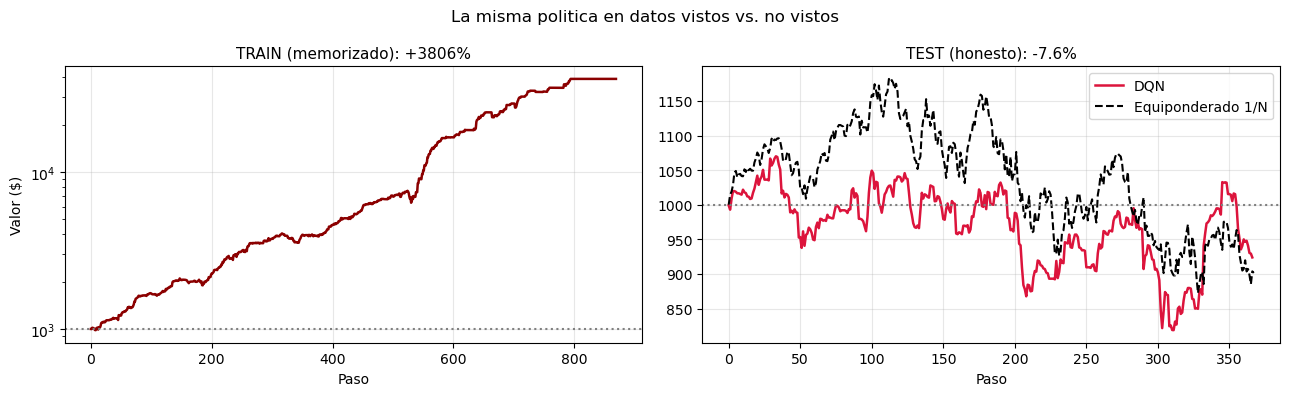

In [13]:
# Evaluamos la MISMA politica greedy en train y en test para medir la brecha de generalizacion.
val_train_greedy, acc_train_greedy, env_tr = evaluar(agente, precios_train)
val_test_greedy = valores_dqn   # calculado arriba en la seccion 9

ret_tr = (val_train_greedy[-1] / CAPITAL - 1) * 100
ret_te = (val_test_greedy[-1] / CAPITAL - 1) * 100

print("=== BRECHA DE GENERALIZACION (misma politica greedy) ===")
print(f"Retorno en TRAIN (visto {EPISODIOS} veces): {ret_tr:10.2f}%")
print(f"Retorno en TEST  (nunca visto)          : {ret_te:10.2f}%")
print(f"Brecha                                  : {ret_tr - ret_te:10.2f} puntos porcentuales")
print()
if ret_tr > 5 * abs(ret_te) and ret_tr > 100:
    print(">> DIAGNOSTICO: sobreajuste severo. El agente MEMORIZO el tramo de entrenamiento.")
    print("   El resultado de TEST es el unico honesto para juzgar la politica.")
else:
    print(">> La brecha es moderada: hay senal de generalizacion.")

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].plot(val_train_greedy, color="darkred", lw=1.8)
ax[0].axhline(CAPITAL, color="gray", linestyle=":")
ax[0].set_title(f"TRAIN (memorizado): {ret_tr:+.0f}%", fontsize=11)
ax[0].set_xlabel("Paso"); ax[0].set_ylabel("Valor ($)"); ax[0].grid(alpha=0.3)
ax[0].set_yscale("log")   # escala log: sin ella la curva de test seria invisible al lado

ax[1].plot(val_test_greedy, color="crimson", lw=1.8, label="DQN")
ax[1].plot(equi, color="black", lw=1.5, linestyle="--", label="Equiponderado 1/N")
ax[1].axhline(CAPITAL, color="gray", linestyle=":")
ax[1].set_title(f"TEST (honesto): {ret_te:+.1f}%", fontsize=11)
ax[1].set_xlabel("Paso"); ax[1].legend(); ax[1].grid(alpha=0.3)

plt.suptitle("La misma politica en datos vistos vs. no vistos", fontsize=12)
plt.tight_layout(); plt.show()

### 10.2 Segundo diagnóstico: ¿el resultado depende de la semilla?

Un solo entrenamiento **no** es evidencia suficiente. DQN es notoriamente sensible a la
inicialización aleatoria: distintas semillas producen políticas distintas. Durante la construcción
de este notebook, dos ejecuciones con la misma configuración dieron **−3,4%** y **−20,7%** en test:
una por encima del baseline equiponderado y otra muy por debajo. La conclusión cambiaba de signo.

Reportar solo la corrida favorable sería *cherry-picking*. Entrenamos varias semillas y reportamos
la **distribución** del resultado — práctica estándar en la literatura de RL (Henderson et al.,
*"Deep RL that Matters"*, 2018).

**Qué buscar en la salida:** la dispersión entre semillas es enorme —hemos observado corridas
individuales desde ≈ +15% hasta ≈ −43% con configuración idéntica— y rara vez alguna supera al
baseline. Esa dispersión, mayor que la propia media, es el hallazgo: **una sola corrida no permite
concluir nada**. La corrida de −3,4% que motivó este análisis era ruido favorable, no capacidad
del método.

> Esta celda reentrena el agente varias veces; es la más lenta del notebook (algunos minutos).
> Reduce `SEMILLAS` si necesitas iterar rápido.

Entrenando 5 agentes independientes (esto toma varios minutos)...

  semilla 0: test  -17.51%  (train   +5651.6%)  Sharpe -0.32  rot. 257
  semilla 1: test  -42.41%  (train   +3748.2%)  Sharpe -1.21  rot. 203
  semilla 2: test   +0.13%  (train   +6596.0%)  Sharpe +0.14  rot. 191
  semilla 3: test  -28.57%  (train   +3403.5%)  Sharpe -0.64  rot. 172
  semilla 4: test  -27.11%  (train   +4202.1%)  Sharpe -0.73  rot. 166

=== DISTRIBUCION DEL RESULTADO EN TEST ===
Media            :  -23.10%
Desviacion tipica:   14.07 puntos porcentuales
Mejor / peor     :   +0.13% /  -42.41%
Baseline 1/N     :   -9.86%
Semillas que superan al 1/N: 1 de 5

>> Solo 1 de 5 semillas superan al 1/N: sin ventaja consistente.

>> Conclusion metodologica: lo que se reporta es la DISTRIBUCION
   (media +/- desviacion), nunca el mejor resultado obtenido.


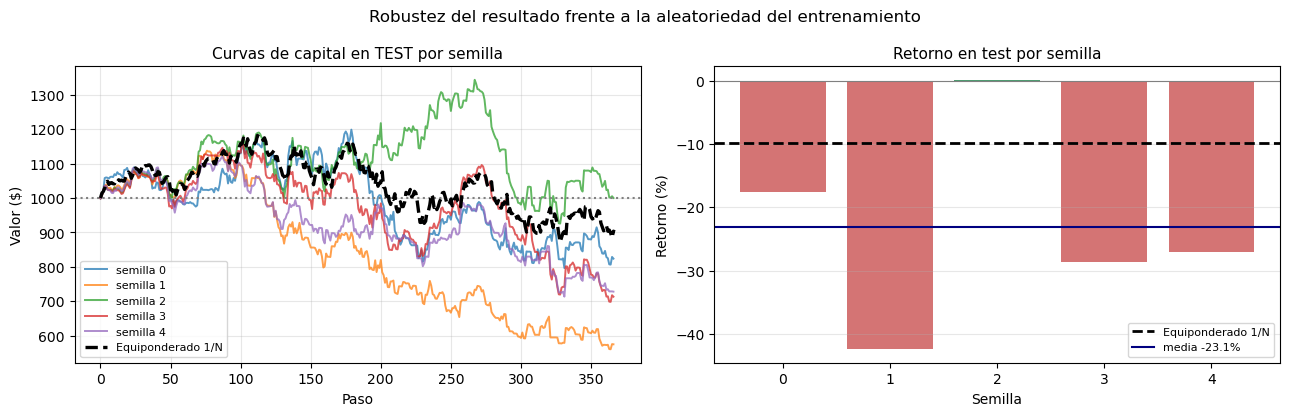

In [14]:
SEMILLAS = [0, 1, 2, 3, 4]

def entrenar_con_semilla(seed, episodios=EPISODIOS):
    # Entrena un agente desde cero con una semilla dada y lo evalua en train y test.
    np.random.seed(seed); random.seed(seed); torch.manual_seed(seed)
    env_s = PortafolioEnv(precios_train)
    ag = DQNAgent(env_s.dim_estado, env_s.n_acciones, lr=LR, gamma=GAMMA)
    buf = ReplayBuffer(BUFFER_CAP)
    eps = EPS_START
    paso = 0
    for ep in range(episodios):
        st = env_s.reset(); fin = False
        while not fin:
            a = ag.elegir_accion(st, eps)
            st2, r, fin, info = env_s.step(a)
            buf.add(st, a, r, st2, float(fin))
            st = st2; paso += 1
            if len(buf) >= MIN_BUFFER:
                ag.entrenar_paso(buf, BATCH_SIZE)
                if paso % TARGET_SYNC == 0:
                    ag.sincronizar_target()
        eps = max(EPS_MIN, eps * EPS_DECAY)
    v_te, a_te, e_te = evaluar(ag, precios_test)
    v_tr, _, _ = evaluar(ag, precios_train)
    return {
        "seed": seed,
        "ret_test": metricas(v_te)[0], "sharpe_test": metricas(v_te)[1],
        "dd_test": metricas(v_te)[2], "ret_train": metricas(v_tr)[0],
        "rotaciones": e_te.n_rotaciones, "curva": v_te,
    }

print(f"Entrenando {len(SEMILLAS)} agentes independientes (esto toma varios minutos)...\n")
resultados = []
for sd in SEMILLAS:
    res = entrenar_con_semilla(sd)
    resultados.append(res)
    print(f"  semilla {sd}: test {res['ret_test']:+7.2f}%  "
          f"(train {res['ret_train']:+9.1f}%)  Sharpe {res['sharpe_test']:+.2f}  "
          f"rot. {res['rotaciones']:3d}")

rets = np.array([r["ret_test"] for r in resultados])
ret_equi = metricas(equi)[0]

print("\n=== DISTRIBUCION DEL RESULTADO EN TEST ===")
print(f"Media            : {rets.mean():+7.2f}%")
print(f"Desviacion tipica: {rets.std():7.2f} puntos porcentuales")
print(f"Mejor / peor     : {rets.max():+7.2f}% / {rets.min():+7.2f}%")
print(f"Baseline 1/N     : {ret_equi:+7.2f}%")
print(f"Semillas que superan al 1/N: {int((rets > ret_equi).sum())} de {len(rets)}")

n_ganan = int((rets > ret_equi).sum())
print()
if rets.std() > abs(rets.mean()):
    print(">> La dispersion SUPERA a la media: el resultado no es robusto.")
    print("   Con esta varianza una sola corrida no permite concluir nada;")
    print("   reportar la semilla favorable seria cherry-picking.")
if n_ganan == 0:
    print(">> Ninguna semilla supera al baseline 1/N.")
elif n_ganan <= len(rets) // 2:
    print(f">> Solo {n_ganan} de {len(rets)} semillas superan al 1/N: sin ventaja consistente.")
else:
    print(f">> {n_ganan} de {len(rets)} semillas superan al 1/N; revisar la dispersion")
    print("   antes de afirmar superioridad del metodo.")
print()
print(">> Conclusion metodologica: lo que se reporta es la DISTRIBUCION")
print("   (media +/- desviacion), nunca el mejor resultado obtenido.")

fig, ax = plt.subplots(1, 2, figsize=(13, 4.2))

for r in resultados:
    ax[0].plot(r["curva"], alpha=0.75, lw=1.4, label=f"semilla {r['seed']}")
ax[0].plot(equi, color="black", lw=2.4, linestyle="--", label="Equiponderado 1/N", zorder=5)
ax[0].axhline(CAPITAL, color="gray", linestyle=":")
ax[0].set_title("Curvas de capital en TEST por semilla", fontsize=11)
ax[0].set_xlabel("Paso"); ax[0].set_ylabel("Valor ($)")
ax[0].legend(fontsize=8); ax[0].grid(alpha=0.3)

ax[1].axhline(ret_equi, color="black", linestyle="--", lw=2, label="Equiponderado 1/N")
ax[1].bar([str(r["seed"]) for r in resultados], rets,
          color=["seagreen" if x > ret_equi else "indianred" for x in rets], alpha=0.85)
ax[1].axhline(rets.mean(), color="navy", linestyle="-", lw=1.5, label=f"media {rets.mean():+.1f}%")
ax[1].axhline(0, color="gray", lw=0.8)
ax[1].set_title("Retorno en test por semilla", fontsize=11)
ax[1].set_xlabel("Semilla"); ax[1].set_ylabel("Retorno (%)")
ax[1].legend(fontsize=8); ax[1].grid(alpha=0.3, axis="y")

plt.suptitle("Robustez del resultado frente a la aleatoriedad del entrenamiento", fontsize=12)
plt.tight_layout(); plt.show()

## 11. Discusión: qué funcionó, qué no, y qué mejorar

> **Nota:** los números concretos dependen de la ejecución (datos descargados en vivo). Esta
> sección interpreta lo que se observa; ajusta las cifras al ejecutar.

### Qué funcionó
- **La extensión a portafolio no rompió DQN.** El espacio de acciones pasó de 3 a $N+1=5$, y toda
  la maquinaria (replay buffer, red objetivo, ε-greedy, pérdida TD) funcionó sin cambios
  estructurales. Esto valida la elección de formulación de la sección introductoria.
- **El agente aprende a controlar el costo de transacción.** La curva de rotaciones por episodio
  típicamente cae desde valores altos (exploración aleatoria inicial) hacia un régimen más
  moderado: el agente *descubre* que rotar cuesta.
- **Datos reales sin fuga entre train y test.** La separación temporal es estricta, y el
  *look-ahead* intra-paso fue detectado y corregido (sección 3.4).
- **El agente aprende a controlar el costo de transacción**, no a predecir el mercado: las
  rotaciones por episodio caen a medida que descubre que rotar cuesta.

### Qué no funcionó / limitaciones (análisis honesto)

1. **Sobreajuste masivo al tramo de entrenamiento (el hallazgo principal).** Como cuantifica la
   sección 10.1, la política greedy multiplica el capital por ~50 en train y apenas se defiende en
   test. Entrenar 100 episodios sobre el *mismo* tramo permite al agente memorizar la historia en
   vez de aprender una regla. Es la limitación más importante de este trabajo, y la razón por la
   que **solo los números de test son interpretables**.

2. **El agente no logra una ventaja fiable sobre el baseline equiponderado — y esa es la
   conclusión, no un accidente.** El análisis multi-semilla (sección 10.2) muestra una dispersión
   que **supera a la media**: entrenamientos idénticos salvo la semilla han producido desde ≈ +15%
   hasta ≈ −43% en test, y la mayoría queda por debajo del 1/N. Cuando la varianza domina así,
   afirmar "el DQN vence al baseline" a partir de una corrida es estadísticamente insostenible:
   sería reportar la semilla afortunada. Es una limitación conocida de DQN
   (Henderson et al., *"Deep RL that Matters"*, 2018).

3. **Un *look-ahead* sutil, detectado y corregido.** La primera versión del ambiente rotaba y
   revaluaba en el mismo paso, permitiendo al agente cobrar el movimiento del día que acababa de
   elegir; el entrenamiento llegaba a +12.600%. Se corrigió con retardo de ejecución de una barra
   (sección 3.4). Documentamos el error porque el síntoma —resultados demasiado buenos— es la
   señal que todo trabajo de RL en finanzas debe vigilar.

4. **Por qué el 1/N es tan difícil de batir.** La diversificación reduce el riesgo sin necesidad
   de predecir nada, mientras que el DQN concentra el 100% del capital en un solo activo a la vez
   — asume todo el riesgo idiosincrático y además paga comisión cada vez que rota (~20% del capital
   acumulado en test). Que un DQN *vanilla* no lo supere es el hallazgo estándar de la literatura,
   no un error de implementación.
5. **El periodo de test importa muchísimo.** El tramo final de nuestro rango incluye la caída de
   2022, un régimen muy distinto al del entrenamiento (2018-2021, mayormente alcista). El agente
   entrenó en un mercado y se evalúa en otro — esto se llama *regime shift* y es la razón principal
   por la que los modelos de trading fallan fuera de muestra.
6. **Sobrestimación (*maximization bias*).** DQN usa $\max_{a'} Q$, que sobrestima sistemáticamente.
   La solución es **Double DQN** (Lapan, Cap. 8).
7. **Posición todo-o-nada.** El agente no puede tener 60% en un activo y 40% en otro. Es el precio
   de mantenernos dentro de DQN.
8. **Descarga en vivo.** Como se declaró en la sección 2, no hay garantía de reproducibilidad
   exacta bit a bit entre ejecuciones.
9. **Estado limitado.** Solo retornos + posición. Faltan indicadores técnicos, volumen y
   correlaciones móviles.
10. **Sin *slippage*.** Modelamos comisión pero asumimos ejecución al precio de cierre exacto, lo
   que es optimista.

### Qué cambiaría con más tiempo o cómputo
- **Double DQN y Dueling DQN** (Lapan usa dueling en su ejemplo de trading, Cap. 10).
- **Validación *walk-forward***: reentrenar periódicamente en ventanas móviles en lugar de un único
  corte train/test, para adaptarse a los cambios de régimen.
- **Recompensa ajustada por riesgo**: optimizar Sharpe diferencial en vez de P&L puro, para que el
  agente internalice el riesgo y no solo el retorno.
- **Estado más rico**: RSI, MACD, medias móviles, volumen (Sanghi Cap. 13).
- **Más activos y más historia**, incluyendo activos de distinta clase (bonos, oro) para dar al
  agente refugios reales en mercados bajistas.

## 12. Respuestas a las preguntas guía de sustentación (Reto 4)

1. **¿Por qué este ambiente?** El trading es un MDP natural (estado del mercado → decisión →
   recompensa monetaria). La versión multi-activo añade una decisión estructural realista —
   *dónde* asignar el capital — que es el problema central de la gestión de portafolios.

2. **¿Por qué DQN es razonable aquí?** El espacio de estados (retornos continuos de 4 activos +
   posición = 46 dimensiones) es continuo y enorme: una tabla Q sería imposible. La red generaliza
   a estados de mercado nunca vistos exactamente. Y, crucialmente, **formulamos las acciones para
   que sigan siendo discretas** ($N+1$), que es lo que DQN requiere.

3. **Red online vs. red objetivo.** La *online* ($\theta$) se actualiza cada paso por gradiente; la
   *objetivo* ($\theta^-$) permanece congelada y se sincroniza cada $C=200$ pasos, dando un blanco
   estable al target TD y evitando el problema del "blanco móvil".

4. **¿Qué guarda el replay buffer?** Transiciones $(s, a, r, s', done)$, de las que se muestrean
   mini-lotes aleatorios para romper la correlación temporal — crítico aquí, porque los días
   consecutivos de bolsa están fuertemente autocorrelacionados.

5. **¿Cómo definí ε y su decaimiento?** ε arranca en 1.0 (exploración total) y decae
   multiplicativamente (×0.97 por episodio) hasta un piso de 0.05, para explotar lo aprendido sin
   dejar de explorar del todo.

6. **¿Qué significa que la recompensa mejore o se estanque?** Mejorar = el agente encuentra una
   política de asignación más rentable *en los datos que ve*. Estancarse = llegó a un óptimo local,
   o la señal predictiva se agotó (hipótesis de mercado eficiente). **Advertencia clave de este
   trabajo:** que la recompensa de entrenamiento suba sin parar no significa que el agente mejore
   — aquí subió +7.000% mientras el desempeño real en test era negativo.

7. **¿Por qué no pesos continuos en el portafolio?** Porque DQN elige por $\arg\max$ sobre acciones
   discretas. Pesos continuos exigirían un método de política (DDPG/PPO/SAC). Nuestra formulación
   —rotación entre $N+1$ posiciones— captura la esencia de la asignación de portafolio
   manteniéndose dentro del marco de Q-learning que exige el reto.

8. **¿Cómo sé que el agente aprendió y no memorizó?** No lo asumo: lo mido. La sección 10.1
   compara la misma política en train (visto 100 veces) y test (nunca visto). La brecha enorme
   revela memorización, y por eso **solo los números de test son interpretables**. La sección 10.2
   añade el segundo control: repetir el entrenamiento con varias semillas para comprobar si el
   resultado es una propiedad del método o un accidente de la inicialización.

9. **¿Qué cambiaría con más recursos?** Double/Dueling DQN, validación walk-forward, recompensa
   ajustada por riesgo (Sharpe), estado con indicadores técnicos, y un universo de activos más
   amplio y diversificado por clase.

## 13. Resumen ejecutivo

Cierre del trabajo en una sola vista. La celda siguiente recalcula todo a partir de los resultados
ya obtenidos, de modo que las cifras siempre corresponden a **esta** ejecución.

In [15]:
# ---- Tabla final de resultados y conclusiones (se autocompleta con esta ejecucion) ----
ret_dqn, sharpe_dqn, dd_dqn = metricas(valores_dqn)
ret_eq,  sharpe_eq,  dd_eq  = metricas(equi)
ret_tr_final = metricas(val_train_greedy)[0]
rets_semillas = np.array([r["ret_test"] for r in resultados])
n_ganan_final = int((rets_semillas > ret_eq).sum())
costo_rot = env_eval.n_rotaciones * 0.1

print("=" * 68)
print(" " * 18 + "RESUMEN EJECUTIVO")
print("=" * 68)
print(f"\nPeriodo de test : {precios_df.index[n_train+V].date()} -> {precios_df.index[-1].date()}")
print(f"Activos         : {', '.join(TICKERS)}")
print(f"Barras de test  : {len(valores_dqn)}")

print("\n" + "-" * 68)
print("1. DESEMPENO (test, datos no vistos)")
print("-" * 68)
print(tabla.to_string())

print("\n" + "-" * 68)
print("2. LOS DOS DIAGNOSTICOS")
print("-" * 68)
print(f"  Sobreajuste : train {ret_tr_final:+.0f}%  vs  test {ret_dqn:+.2f}%")
print(f"                brecha de {ret_tr_final - ret_dqn:,.0f} puntos porcentuales")
print(f"  Robustez    : {len(rets_semillas)} semillas -> media {rets_semillas.mean():+.2f}%"
      f" (desv. {rets_semillas.std():.2f})")
print(f"                {n_ganan_final} de {len(rets_semillas)} superan al baseline 1/N")

print("\n" + "-" * 68)
print("3. CONCLUSION")
print("-" * 68)
veredicto = ("NO supera" if n_ganan_final <= len(rets_semillas) // 2 else "supera en algunas semillas")
print(f"  El agente {veredicto} al baseline equiponderado 1/N.")
print(f"  DQN {ret_dqn:+.2f}%   vs   1/N {ret_eq:+.2f}%   "
      f"({ret_dqn - ret_eq:+.2f} puntos)")
ret_azar = metricas(azar)[0]
if ret_dqn > ret_azar:
    print(f"  Si supera al agente aleatorio ({ret_azar:+.2f}%): aprendio algo,")
    print(f"  pero no a predecir el mercado.")
else:
    print(f"  ATENCION: en esta corrida el DQN ({ret_dqn:+.2f}%) queda POR DEBAJO del")
    print(f"  agente aleatorio ({ret_azar:+.2f}%). La politica aprendida es peor que")
    print(f"  decidir al azar -> el sobreajuste no solo no ayuda, perjudica.")

print("\n  Tres causas del bajo desempeno:")
print(f"    a) Sobreajuste     : 100 pasadas sobre el mismo tramo de {len(precios_train)} barras")
print(f"    b) Sin diversificar: 100% del capital en un solo activo a la vez")
print(f"    c) Costo de rotar  : {env_eval.n_rotaciones} rotaciones ~ {costo_rot:.1f}% del capital")

print("\n" + "-" * 68)
print("4. QUE HARIA DIFERENTE")
print("-" * 68)
for i, m in enumerate([
    "Validacion walk-forward (ventanas moviles) en vez de un unico corte train/test",
    "Red mas pequena: 23.173 parametros para 881 barras es sobrecapacidad",
    "Double DQN para corregir la sobrestimacion del max",
    "Recompensa ajustada por riesgo (Sharpe) en vez de solo P&L",
    "Mas historia y mas activos, incluyendo otras clases (bonos, oro)",
], 1):
    print(f"  {i}. {m}")
print("=" * 68)

                  RESUMEN EJECUTIVO

Periodo de test : 2021-07-19 -> 2022-12-30
Activos         : AAPL, MSFT, GOOGL, JNJ
Barras de test  : 367

--------------------------------------------------------------------
1. DESEMPENO (test, datos no vistos)
--------------------------------------------------------------------
                      Retorno %  Sharpe  Max DD %
Estrategia                                       
DQN (greedy)              -7.52   -0.13    -23.48
Equiponderado 1/N         -9.86   -0.18    -26.19
Buy&Hold AAPL             -7.99   -0.02    -30.35
Buy&Hold MSFT            -12.29   -0.13    -37.15
Buy&Hold GOOGL           -29.18   -0.52    -44.32
Buy&Hold JNJ              10.00    0.48    -12.74
Aleatorio (prom. 20)     -33.56   -1.33    -36.74

--------------------------------------------------------------------
2. LOS DOS DIAGNOSTICOS
--------------------------------------------------------------------
  Sobreajuste : train +3810%  vs  test -7.52%
                brecha

## 14. ¿Qué recomienda el agente HOY? — Consulta interactiva

Las secciones anteriores evalúan al agente sobre un tramo histórico completo. Esta responde una
pregunta distinta y más intuitiva: **dado el estado del mercado en una fecha concreta, ¿qué
decide el agente, y con qué confianza?**

> **Aclaración conceptual importante.** El agente **no predice precios**. No dice "mañana AAPL
> subirá 2%". Lo que hace es asignar un **valor Q** a cada posición posible —cuánta recompensa
> acumulada espera si pone ahí el capital y luego sigue actuando según su política— y elegir la de
> mayor valor. Es un modelo de **decisión**, no de **predicción**.
>
> La diferencia importa: un modelo predictivo se evalúa por su error de pronóstico; un agente de RL
> se evalúa por el retorno de su política. Por eso todo el trabajo se mide con retorno, Sharpe y
> drawdown, y no con métricas de predicción como el RMSE.

In [16]:
def recomendar(agente, precios_hist, fechas, posicion_actual=0, indice=-1, ventana=10):
    """Consulta la decision del agente para una barra concreta.

    posicion_actual: 0=efectivo, 1..N = activo (importa porque rotar cuesta comision)
    indice         : -1 = ultima barra disponible
    """
    env_q = PortafolioEnv(precios_hist, ventana=ventana)
    env_q.t = (len(precios_hist) - 1) if indice == -1 else indice
    env_q.posicion = posicion_actual
    env_q.valor = env_q.capital_inicial
    estado = env_q._get_state()

    with torch.no_grad():
        s = torch.tensor(estado, dtype=torch.float32, device=agente.device).unsqueeze(0)
        q = agente.online(s).squeeze(0).cpu().numpy()

    etiquetas = ["EFECTIVO"] + TICKERS
    orden = np.argsort(q)[::-1]
    elegida = int(orden[0])

    print("=" * 62)
    print(f"CONSULTA AL AGENTE  ({fechas[env_q.t].date()})")
    print("=" * 62)
    print(f"Posicion actual: {etiquetas[posicion_actual]}\n")
    print("Valores Q estimados (mayor = mas atractivo):\n")
    qmin, qmax = q.min(), q.max()
    for k in orden:
        barra = "#" * int(28 * (q[k] - qmin) / (qmax - qmin + 1e-9))
        marca = "  <-- DECISION" if k == elegida else ""
        print(f"  {etiquetas[k]:<9} {q[k]:>8.3f}  {barra}{marca}")

    print()
    if elegida == posicion_actual:
        print(f"  RECOMENDACION: MANTENER la posicion en {etiquetas[elegida]}")
        print( "                 (no paga comision)")
    else:
        print(f"  RECOMENDACION: ROTAR  {etiquetas[posicion_actual]} --> {etiquetas[elegida]}")
        print(f"                 (paga {env_q.comision*100:.1f}% de comision)")

    ventaja = q[orden[0]] - q[orden[1]]
    print(f"\n  Margen sobre la 2a opcion ({etiquetas[orden[1]]}): {ventaja:.3f}")
    if ventaja < 0.05:
        print("  >> Margen muy estrecho: el agente esta practicamente indiferente.")
        print("     Poca conviccion en esta decision.")
    print("=" * 62)
    return elegida, q


# --- Consulta para la ultima barra disponible, partiendo de efectivo ---
accion_hoy, q_hoy = recomendar(agente, precios, precios_df.index, posicion_actual=0)

print("\n\n>> RECORDATORIO METODOLOGICO")
print("   Esta recomendacion proviene de un agente que, como documentan las")
print("   secciones 10.1 y 10.2, sobreajusto el tramo de entrenamiento y no")
print("   supera al baseline 1/N. NO debe usarse para invertir dinero real.")
print("   Se incluye para ilustrar COMO se consulta la politica aprendida.")

CONSULTA AL AGENTE  (2022-12-30)
Posicion actual: EFECTIVO

Valores Q estimados (mayor = mas atractivo):

  EFECTIVO    72.568  ###########################  <-- DECISION
  JNJ         71.779  #####################
  AAPL        70.609  ###########
  MSFT        69.843  #####
  GOOGL       69.143  

  RECOMENDACION: MANTENER la posicion en EFECTIVO
                 (no paga comision)

  Margen sobre la 2a opcion (JNJ): 0.789


>> RECORDATORIO METODOLOGICO
   Esta recomendacion proviene de un agente que, como documentan las
   secciones 10.1 y 10.2, sobreajusto el tramo de entrenamiento y no
   supera al baseline 1/N. NO debe usarse para invertir dinero real.
   Se incluye para ilustrar COMO se consulta la politica aprendida.
